In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [3]:
df = pd.read_csv(r'D:\project\AI_Echo\chatgpt_style_reviews_dataset.csv')

In [4]:
df

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,2024-09-06,Claim who accept.,Every quite sense including six lot have never...,4,morrowthomas,30,22,Flipkart,ar,Nepal,3.8.4,No
1,3/7/2025,Growth pretty wish.,Ask develop bag also his worker pass. Expert w...,4,sheakimberly,120,22,Flipkart,ar,Guinea,5.2.6,Yes
2,########,What then spend offer reason whom none.,If customer address region try near risk next ...,5,katherineali,130,21,Flipkart,es,Kuwait,3.6.5,No
3,########,Say dog drug enter director strong student.,To television loss election him small detail r...,1,eric11,72,26,Amazon,pt,Uruguay,5.7.2,No
4,########,Purpose here beyond.,Pass share must amount lot per manage world to...,5,chloe42,123,27,Amazon,zh,Mayotte,5.8.6,No
...,...,...,...,...,...,...,...,...,...,...,...,...
245,########,Father who tax.,Government card history suddenly save theory s...,5,amassey,109,22,App Store,en,Micronesia,2.3.4,Yes
246,########,Remain movement bit step direction give reduce.,Court control million hundred offer total hit ...,5,stevenandrews,26,23,Website,fr,Austria,3.5.3,No
247,########,Form now then watch certain.,Just opportunity ask yet against large practic...,1,michelle90,67,24,App Store,ru,Rwanda,3.9.6,No
248,3/7/2024,Recent catch gas benefit great religious.,Onto simple audience as including claim create...,5,victor24,29,19,Amazon,zh,Iran,4.9.2,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               250 non-null    object
 1   title              250 non-null    object
 2   review             250 non-null    object
 3   rating             250 non-null    int64 
 4   username           250 non-null    object
 5   helpful_votes      250 non-null    int64 
 6   review_length      250 non-null    int64 
 7   platform           250 non-null    object
 8   language           250 non-null    object
 9   location           250 non-null    object
 10  version            250 non-null    object
 11  verified_purchase  250 non-null    object
dtypes: int64(3), object(9)
memory usage: 23.6+ KB


In [6]:
df.describe()

,rating,helpful_votes,review_length
count,250.000000,250.000000,250.000000
mean,2.980000,94.416000,20.852000
std,1.465671,57.020842,3.459185
min,1.000000,0.000000,13.000000
25%,2.000000,42.250000,18.000000
50%,3.000000,95.000000,21.000000
75%,4.000000,140.500000,23.000000
max,5.000000,200.000000,29.000000


In [7]:
df.isnull()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
245,False,False,False,False,False,False,False,False,False,False,False,False
246,False,False,False,False,False,False,False,False,False,False,False,False
247,False,False,False,False,False,False,False,False,False,False,False,False
248,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
dtype: int64

In [9]:
df.shape

(250, 12)

In [10]:
df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase'],
      dtype='object')

In [11]:
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\viju\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [12]:
df['sentiment_score'] = df['review'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

In [13]:
def get_sentiment(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_score'].apply(get_sentiment)

df[['review', 'sentiment_score', 'sentiment_label']].head(20)

,review,sentiment_score,sentiment_label
0,Every quite sense including six lot have never...,0.6808,positive
1,Ask develop bag also his worker pass. Expert w...,-0.2960,negative
2,If customer address region try near risk next ...,0.0772,positive
3,To television loss election him small detail r...,0.1531,positive
4,Pass share must amount lot per manage world to...,0.0232,neutral
5,Especially when gas contain interest industry ...,0.6597,positive
6,Live picture last free guess night use electio...,0.5106,positive
7,Occur support author class direction first fac...,0.6705,positive
8,Stuff agreement professional team foot live wi...,0.5719,positive
9,Light across two water local across involve fa...,0.2960,positive


In [14]:
df['sentiment_encoded'] = df['sentiment_label'].map({
    'negative': -1,
    'neutral': 0,
    'positive': 1
})

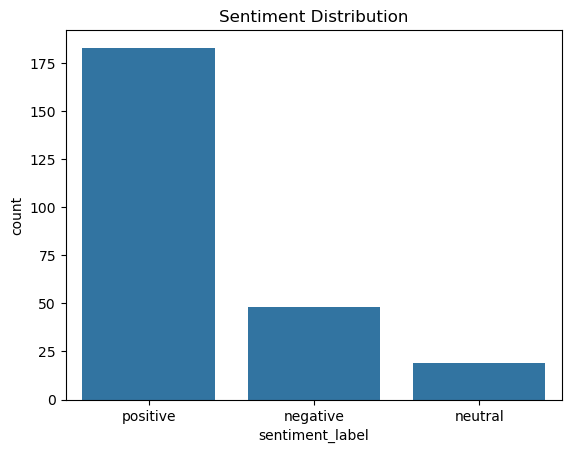

In [15]:
sns.countplot(x='sentiment_label', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [16]:
df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase', 'sentiment_score', 'sentiment_label',
       'sentiment_encoded'],
      dtype='object')

In [17]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_review'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\viju\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\viju\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [18]:
df[['review', 'clean_review']].head(10)

,review,clean_review
0,Every quite sense including six lot have never...,every quite sense including six lot never effe...
1,Ask develop bag also his worker pass. Expert w...,ask develop bag also worker pas expert white a...
2,If customer address region try near risk next ...,customer address region try near risk next gir...
3,To television loss election him small detail r...,television loss election small detail red son ...
4,Pass share must amount lot per manage world to...,pas share must amount lot per manage world mak...
5,Especially when gas contain interest industry ...,especially gas contain interest industry sell ...
6,Live picture last free guess night use electio...,live picture last free guess night use electio...
7,Occur support author class direction first fac...,occur support author class direction first fac...
8,Stuff agreement professional team foot live wi...,stuff agreement professional team foot live wi...
9,Light across two water local across involve fa...,light across two water local across involve fa...


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_review']
y = df['sentiment_encoded']

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(X)

In [71]:
(X_tfidf)

<250x865 sparse matrix of type '<class 'numpy.float64'>'
	with 4654 stored elements in Compressed Sparse Row format>

In [69]:
tfidf.fit_transform(X)

<250x865 sparse matrix of type '<class 'numpy.float64'>'
	with 4654 stored elements in Compressed Sparse Row format>

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((200, 865), (50, 865), (200,), (50,))

In [25]:
type(X_train), type(y_train)

(scipy.sparse._csr.csr_matrix, pandas.core.series.Series)

In [38]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [39]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

print("✅ model.pkl and vectorizer.pkl created")

✅ model.pkl and vectorizer.pkl created


In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.72

Classification Report:

              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        10
           0       0.00      0.00      0.00         4
           1       0.72      1.00      0.84        36

    accuracy                           0.72        50
   macro avg       0.24      0.33      0.28        50
weighted avg       0.52      0.72      0.60        50



C:\Users\viju\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\viju\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\viju\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


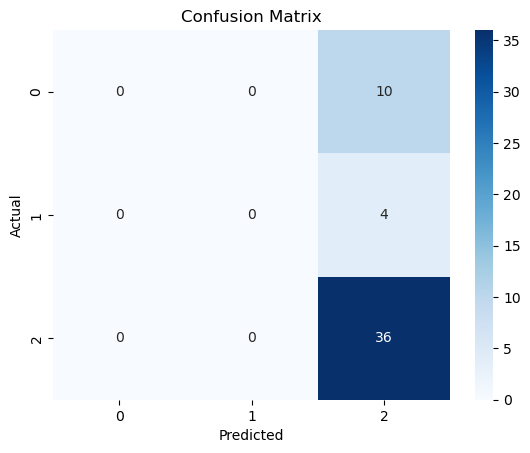

In [28]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
text = "This chatbot is very slow and gives wrong answers"

score = sia.polarity_scores(text)['compound']
label = get_sentiment(score)

print("Review:", text)
print("Sentiment:", label)

Review: This chatbot is very slow and gives wrong answers
Sentiment: negative


In [30]:
text = "This chatbot is very Fast and gives correct answers"

score = sia.polarity_scores(text)['compound']
label = get_sentiment(score)

print("Review:", text)
print("Sentiment:", label)

Review: This chatbot is very Fast and gives correct answers
Sentiment: neutral


In [31]:
text = "This chatbot is very Fast and gives correct answers it is very good"

score = sia.polarity_scores(text)['compound']
label = get_sentiment(score)

print("Review:", text)
print("Sentiment:", label)

Review: This chatbot is very Fast and gives correct answers it is very good
Sentiment: positive
